<p style="align: center;"><img src="https://static.tildacdn.com/tild6636-3531-4239-b465-376364646465/Deep_Learning_School.png" width="400"></p>

# Домашнее задание. Обучение языковой модели с помощью LSTM (10 баллов)

Э
В этом задании Вам предстоит обучить языковую модель с помощью рекуррентной нейронной сети. В отличие от семинарского занятия, Вам необходимо будет работать с отдельными словами, а не буквами.


Установим модуль ```datasets```, чтобы нам проще было работать с данными.

In [1]:
!pip install datasets

Импорт необходимых библиотек

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from datasets import load_dataset
from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.model_selection import train_test_split
import nltk

from collections import Counter
from typing import List

import seaborn
seaborn.set(palette='summer')

In [2]:
#nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\VolkovAP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

## Подготовка данных

Воспользуемся датасетом imdb. В нем хранятся отзывы о фильмах с сайта imdb. Загрузим данные с помощью функции ```load_dataset```

In [4]:
# Загрузим датасет
dataset = load_dataset('imdb')

### Препроцессинг данных и создание словаря (1 балл)

Далее вам необходмо самостоятельно произвести препроцессинг данных и получить словарь или же просто ```set``` строк. Что необходимо сделать:

1. Разделить отдельные тренировочные примеры на отдельные предложения с помощью функции ```sent_tokenize``` из бибилиотеки ```nltk```. Каждое отдельное предложение будет одним тренировочным примером.
2. Оставить только те предложения, в которых меньше ```word_threshold``` слов.
3. Посчитать частоту вхождения каждого слова в оставшихся предложениях. Для деления предлоения на отдельные слова удобно использовать функцию ```word_tokenize```.
4. Создать объект ```vocab``` класса ```set```, положить в него служебные токены '\<unk\>', '\<bos\>', '\<eos\>', '\<pad\>' и vocab_size самых частовстречающихся слов.   

In [44]:
sentences = []
word_threshold = 32

for one_text in tqdm(dataset['train']['text']):
    tokenized_sentences = [sentence.lower() for sentence in sent_tokenize(one_text, language='russian')]
    sentences.extend([sentence for sentence in tokenized_sentences if len(sentence.split()) < word_threshold])

  0%|          | 0/25000 [00:00<?, ?it/s]

In [45]:
print("Всего предложений:", len(sentences))

Всего предложений: 222000


Посчитаем для каждого слова его встречаемость.

In [46]:
words = Counter()

for sentence in tqdm(sentences):
    for word in word_tokenize(sentence):
        words[word] += 1

  0%|          | 0/222000 [00:00<?, ?it/s]

Добавим в словарь ```vocab_size``` самых встречающихся слов.

In [47]:
vocab = set()
vocab_size = 40000

vocab = set(['<unk>', '<bos>', '<eos>', '<pad>'])

for word, _ in words.most_common(vocab_size):
    vocab.add(word)

In [48]:
assert '<unk>' in vocab
assert '<bos>' in vocab
assert '<eos>' in vocab
assert '<pad>' in vocab
assert len(vocab) == vocab_size + 4

In [49]:
print("Всего слов в словаре:", len(vocab))

Всего слов в словаре: 40004


### Подготовка датасета (1 балл)

Далее, как и в семинарском занятии, подготовим датасеты и даталоадеры.

В классе ```WordDataset``` вам необходимо реализовать метод ```__getitem__```, который будет возвращать сэмпл данных по входному idx, то есть список целых чисел (индексов слов).

Внутри этого метода необходимо добавить служебные токены начала и конца последовательности, а также токенизировать соответствующее предложение с помощью ```word_tokenize``` и сопоставить ему индексы из ```word2ind```.

In [50]:
word2ind = {char: i for i, char in enumerate(vocab)}
ind2word = {i: char for char, i in word2ind.items()}

In [51]:
import string

class WordDataset:
    def __init__(self, sentences):
        self.data = sentences
        self.unk_id = word2ind['<unk>']
        self.bos_id = word2ind['<bos>']
        self.eos_id = word2ind['<eos>']
        self.pad_id = word2ind['<pad>']

    def __getitem__(self, idx: int) -> List[int]:
        tokenized_sentence = [self.bos_id]
        processed_sentence = self.data[idx].lower().translate(
            str.maketrans('','', string.punctuation)
        )
        tokenized_sentence += [word2ind.get(word, self.unk_id) for word in word_tokenize(processed_sentence)]
        tokenized_sentence += [self.eos_id]

        return tokenized_sentence

    def __len__(self) -> int:
        return len(self.data)

In [52]:
def collate_fn_with_padding(
    input_batch: List[List[int]], pad_id=word2ind['<pad>']) -> torch.Tensor:
    seq_lens = [len(x) for x in input_batch]
    max_seq_len = max(seq_lens)

    new_batch = []
    for sequence in input_batch:
        for _ in range(max_seq_len - len(sequence)):
            sequence.append(pad_id)
        new_batch.append(sequence)

    sequences = torch.LongTensor(new_batch)

    new_batch = {
        'input_ids': sequences[:,:-1],
        'target_ids': sequences[:,1:]
    }

    return new_batch

In [53]:
# Будем оценивать финальное качество модели по валидации

train_sentences, eval_sentences = train_test_split(sentences, test_size=0.2)
#eval_sentences, test_sentences = train_test_split(eval_sentences, test_size=0.5)

train_dataset = WordDataset(train_sentences)
eval_dataset = WordDataset(eval_sentences)
#test_dataset = WordDataset(test_sentences)

batch_size = 128

train_dataloader = DataLoader(
    train_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

eval_dataloader = DataLoader(
    eval_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

#test_dataloader = DataLoader(
#    test_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

## Обучение и архитектура модели

Вам необходимо на практике проверить, что влияет на качество языковых моделей. В этом задании нужно провести серию экспериментов с различными вариантами языковых моделей и сравнить различия в конечной перплексии на тестовом множестве.

Возмоэные идеи для экспериментов:

* Различные RNN-блоки, например, LSTM или GRU. Также можно добавить сразу несколько RNN блоков друг над другом с помощью аргумента num_layers. Вам поможет официальная документация [здесь](https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html)
* Различные размеры скрытого состояния. Различное количество линейных слоев после RNN-блока. Различные функции активации.
* Добавление нормализаций в виде Dropout, BatchNorm или LayerNorm
* Различные аргументы для оптимизации, например, подбор оптимального learning rate или тип алгоритма оптимизации SGD, Adam, RMSProp и другие
* Любые другие идеи и подходы

После проведения экспериментов необходимо составить таблицу результатов, в которой описан каждый эксперимент и посчитана перплексия на тестовом множестве.

Учтите, что эксперименты, которые различаются, например, только размером скрытого состояния или количеством линейных слоев считаются, как один эксперимент.

Успехов!

### Функция evaluate (1 балл)

Заполните функцию ```evaluate```

In [124]:
def evaluate(model, criterion, dataloader, device='cuda') -> float:
    model.eval()
    total_loss = 0.0
    count = 0
    with torch.no_grad():
        for batch in dataloader:
            x = batch['input_ids'].to(device)
            y = batch['target_ids'].to(device)

            logits = model(x)
            loss = criterion(logits.flatten(start_dim=0, end_dim=1),
                             y.flatten())

            total_loss += loss.item()
            count += 1

    mean_loss = total_loss / max(1, count)
    #print(mean_loss)
    ppl = float(torch.exp(torch.tensor(mean_loss)))
    return ppl


### Train loop (1 балл)

Напишите функцию для обучения модели.

In [125]:
best_model_state = None
best_score = float("inf")
best_params_global = None

def train_and_eval(
    rnn_type: str = "gru",
    hidden_size: int = 256,
    num_layers: int = 1,
    emb_size: int = 256,
    dropout: float = 0.1,
    use_dropout: bool = False,
    use_norm: bool = False,
    norm_type: str | None = None,
    activation: str = "tanh",
    num_epoch: int = 5,
    lr: float = 1e-3,
    if_show: bool = True,
    return_model: bool = False,
):
    global best_model_state, best_score, best_params_global

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    pad_id = int(word2ind["<pad>"])

    # модель с опциональными dropout и нормализацией
    model = LanguageModel(
        vocab_size=len(word2ind),
        pad_id=pad_id,
        emb_size=emb_size,
        hidden_size=hidden_size,
        num_layers=num_layers,
        rnn_type=rnn_type,
        dropout=dropout,
        use_dropout=use_dropout,
        use_norm=use_norm,
        norm_type=norm_type,
        activation=activation,
    ).to(device)

    criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses, eval_losses, train_ppls, eval_ppls = [], [], [], []

    for epoch in range(num_epoch):
        model.train()
        total_loss = 0.0
        n_batches = 0
    
        iterator = train_dataloader
        if if_show:
            from tqdm import tqdm
            iterator = tqdm(iterator, desc=f"{rnn_type} H{hidden_size} L{num_layers} epoch {epoch}")
    
        # --- обучение ---
        for batch in iterator:
            optimizer.zero_grad(set_to_none=True)
            x = batch["input_ids"].to(device)
            y = batch["target_ids"].to(device)
    
            logits = model(x)
            loss = criterion(logits.flatten(start_dim=0, end_dim=1),
                             y.flatten())
    
            loss.backward()
            optimizer.step()
    
            total_loss += loss.item()
            n_batches += 1
    
        avg_train_loss = total_loss / n_batches
        train_losses.append(avg_train_loss)
    
        # --- валидация ---
        model.eval()
        with torch.no_grad():
            eval_loss_total = 0.0
            n_batches = 0
            for batch in eval_dataloader:
                x = batch["input_ids"].to(device)
                y = batch["target_ids"].to(device)
    
                logits = model(x)
                loss = criterion(logits.flatten(start_dim=0, end_dim=1),
                                 y.flatten())
    
                eval_loss_total += loss.item()
                n_batches += 1
    
            avg_eval_loss = eval_loss_total / n_batches
    
            train_ppl = evaluate(model, criterion, train_dataloader, device)
            eval_ppl = evaluate(model, criterion, eval_dataloader, device)
    
        eval_losses.append(avg_eval_loss)
        train_ppls.append(train_ppl)
        eval_ppls.append(eval_ppl)

        if if_show:
            print(
                f"Epoch {epoch}: "
                f"train_loss={avg_train_loss:.4f}, eval_loss={avg_eval_loss:.4f}, "
                f"train_ppl={train_ppl:.2f}, eval_ppl={eval_ppl:.2f}"
            )

        if eval_ppl < best_score:
            best_score = eval_ppl
            best_model_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_params_global = {
                "rnn_type": rnn_type,
                "hidden_size": hidden_size,
                "num_layers": num_layers,
                "emb_size": emb_size,
                "dropout": dropout,
                "use_dropout": use_dropout,
                "use_norm": use_norm,
                "norm_type": norm_type,
                "activation": activation,
            }

    results = {
        "train_losses": train_losses,
        "eval_losses": eval_losses,
        "train_ppls": train_ppls,
        "eval_ppls": eval_ppls,
    }

    if return_model:
        return results, model
    return results


In [126]:
import matplotlib.pyplot as plt
import pandas as pd

def visualize_results(results: dict, keys: list[str] = None):
    """
    results: {
        'rnn': {'train_losses': [...], 'eval_losses': [...],
                'train_ppls': [...], 'eval_ppls': [...]},
        'gru': {...}, ...
    }
    keys: список моделей для отображения. Если None — все.
    """
    if keys is None:
        keys = list(results.keys())
    else:
        keys = [k for k in keys if k in results]

    if not keys:
        print("Нет валидных ключей для отображения.")
        return

    colors = plt.get_cmap("tab10").colors

    # --- Losses ---
    plt.figure(figsize=(8, 5))
    for i, name in enumerate(keys):
        c = colors[i % len(colors)]
        plt.plot(results[name]["train_losses"], color=c, linewidth=2.2, label=f"{name} train")
        if "eval_losses" in results[name]:
            plt.plot(results[name]["eval_losses"], "--", color=c, linewidth=2.0, label=f"{name} eval")
    plt.title("Train & Validation Loss per epoch", fontsize=13)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.4)
    plt.show()

    # --- Perplexities ---
    plt.figure(figsize=(8, 5))
    for i, name in enumerate(keys):
        c = colors[i % len(colors)]
        plt.plot(results[name]["train_ppls"], color=c, linewidth=2.2, label=f"{name} train")
        if "eval_ppls" in results[name]:
            plt.plot(results[name]["eval_ppls"], "--", color=c, linewidth=2.0, label=f"{name} eval")
    plt.title("Train & Validation Perplexity", fontsize=13)
    plt.xlabel("Epoch")
    plt.ylabel("Perplexity")
    plt.legend()
    plt.grid(alpha=0.4)
    plt.show()

    # --- Таблица финальных значений ---
    summary = []
    for name in keys:
        data = results[name]
        summary.append({
            "model": name,
            "final_train_loss": data["train_losses"][-1],
            "final_eval_loss": data.get("eval_losses", [None])[-1],
            "final_train_ppl": data.get("train_ppls", [None])[-1],
            "final_eval_ppl": data.get("eval_ppls", [None])[-1],
        })
    df = pd.DataFrame(summary)
    print(df.sort_values(by="final_eval_ppl", ascending=True).reset_index(drop=True))


In [127]:
results = {}

### Первый эксперимент (2 балла)

Определите архитектуру модели и обучите её.

In [128]:
class LanguageModel(nn.Module):
    def __init__(
        self,
        vocab_size,
        pad_id,
        emb_size=256,
        hidden_size=256,
        num_layers=1,
        rnn_type="gru",
        dropout=0.1,
        use_dropout=False,
        use_norm=False,
        norm_type=None,  # 'layernorm', 'batchnorm' или None
        activation="relu",  # 'relu' или 'tanh'
    ):
        super().__init__()
        self.pad_id = pad_id
        self.use_dropout = use_dropout
        self.use_norm = use_norm

        # Эмбеддинги
        self.embedding = nn.Embedding(vocab_size, emb_size, padding_idx=pad_id)

        # RNN-блок
        if rnn_type == "lstm":
            self.rnn = nn.LSTM(
                emb_size,
                hidden_size,
                num_layers,
                batch_first=True,
            )
        elif rnn_type == "gru":
            self.rnn = nn.GRU(
                emb_size,
                hidden_size,
                num_layers,
                batch_first=True,
            )
        else:
            self.rnn = nn.RNN(
                emb_size,
                hidden_size,
                num_layers,
                batch_first=True,
            )

        # Нормализация
        if use_norm:
            if norm_type == "layernorm":
                self.norm = nn.LayerNorm(hidden_size)
            elif norm_type == "batchnorm":
                self.norm = nn.BatchNorm1d(hidden_size)
            else:
                self.norm = nn.Identity()
        else:
            self.norm = nn.Identity()

        # Dropout
        self.dropout = nn.Dropout(dropout) if use_dropout else nn.Identity()

        # Нелинейность
        if activation == "relu":
            self.non_lin = nn.ReLU()
        else:
            self.non_lin = nn.Tanh()

        # Линейные слои
        self.linear = nn.Linear(hidden_size, hidden_size)
        self.projection = nn.Linear(hidden_size, vocab_size)

    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:
        x = self.embedding(input_batch)
        output, _ = self.rnn(x)
        output = self.dropout(output)

        # BatchNorm (B, C, T)
        if self.use_norm and isinstance(self.norm, nn.BatchNorm1d):
            output = self.norm(output.transpose(1, 2)).transpose(1, 2)
        else:
            output = self.norm(output)

        output = self.non_lin(self.linear(output))
        output = self.dropout(output)
        logits = self.projection(self.non_lin(output))

        return logits


In [129]:
np.exp(4)

np.float64(54.598150033144236)

## 1 Различные RNN-блоки, например, LSTM или GRU. Также можно добавить сразу несколько RNN блоков друг над другом с помощью аргумента num_layers. 

In [130]:
# RNN / GRU / LSTM сравнение
for rnn_type in ["rnn", "gru", "lstm"]:
    results[rnn_type] = train_and_eval(rnn_type=rnn_type, num_epoch=10)

rnn H256 L1 epoch 0: 100%|█████████████████████████████████████████████████████████| 1388/1388 [00:50<00:00, 27.43it/s]


Epoch 0: train_loss=6.1280, eval_loss=5.5888, train_ppl=250.75, eval_ppl=267.42


rnn H256 L1 epoch 1: 100%|█████████████████████████████████████████████████████████| 1388/1388 [00:50<00:00, 27.45it/s]


Epoch 1: train_loss=5.3927, eval_loss=5.3263, train_ppl=173.74, eval_ppl=205.67


rnn H256 L1 epoch 2: 100%|█████████████████████████████████████████████████████████| 1388/1388 [00:50<00:00, 27.45it/s]


...

Epoch 7: train_loss=4.4851, eval_loss=5.1473, train_ppl=88.22, eval_ppl=171.97


lstm H256 L1 epoch 8: 100%|████████████████████████████████████████████████████████| 1388/1388 [00:50<00:00, 27.22it/s]


Epoch 8: train_loss=4.4054, eval_loss=5.1713, train_ppl=83.93, eval_ppl=176.14


lstm H256 L1 epoch 9: 100%|████████████████████████████████████████████████████████| 1388/1388 [00:50<00:00, 27.23it/s]


Epoch 9: train_loss=4.3327, eval_loss=5.1987, train_ppl=80.33, eval_ppl=181.04


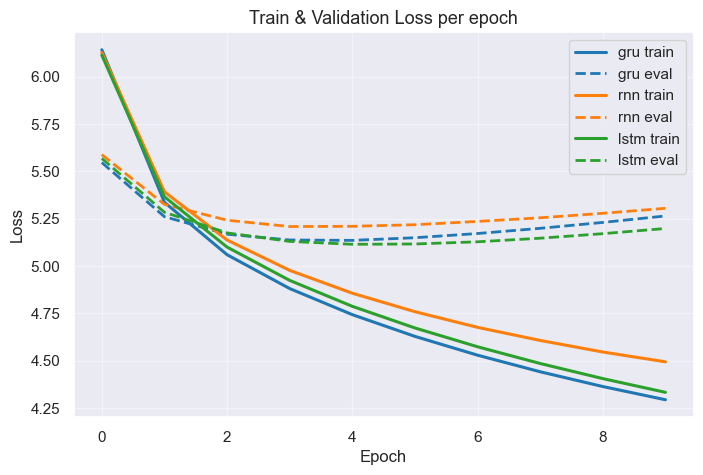

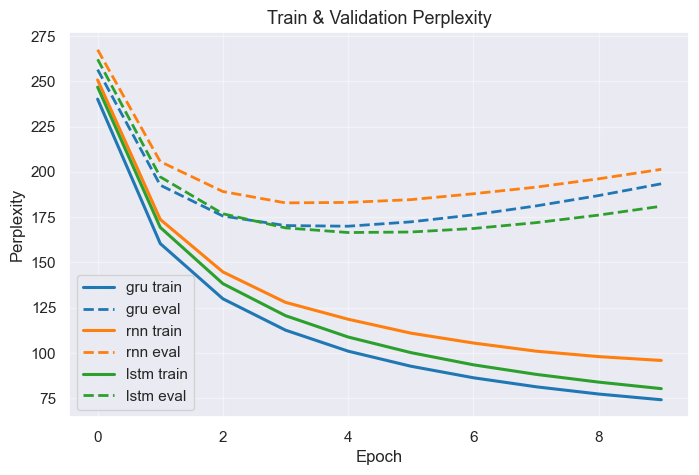

  model  final_train_loss  final_eval_loss  final_train_ppl  final_eval_ppl
0  lstm          4.332730         5.198708        80.334755      181.038193
1   gru          4.293612         5.264893        74.200249      193.425537
2   rnn          4.494097         5.305341        95.882935      201.409622


In [131]:
visualize_results(results, keys=["gru", "rnn", "lstm"])

In [132]:
# Больше слоёв
results["gru_2layers"] = train_and_eval(rnn_type="gru", num_layers=2, num_epoch=10)

results["gru_3layers"] = train_and_eval(rnn_type="gru", num_layers=3, num_epoch=10)

gru H256 L2 epoch 0: 100%|█████████████████████████████████████████████████████████| 1388/1388 [00:52<00:00, 26.62it/s]


Epoch 0: train_loss=6.3622, eval_loss=5.7353, train_ppl=296.93, eval_ppl=309.59


gru H256 L2 epoch 1: 100%|█████████████████████████████████████████████████████████| 1388/1388 [00:52<00:00, 26.63it/s]


Epoch 1: train_loss=5.4763, eval_loss=5.3355, train_ppl=181.06, eval_ppl=207.57


gru H256 L2 epoch 2: 100%|█████████████████████████████████████████████████████████| 1388/1388 [00:52<00:00, 26.56it/s]


...

Epoch 7: train_loss=4.6698, eval_loss=5.2535, train_ppl=112.73, eval_ppl=191.23


gru H256 L3 epoch 8: 100%|█████████████████████████████████████████████████████████| 1388/1388 [00:53<00:00, 25.85it/s]


Epoch 8: train_loss=4.5975, eval_loss=5.2688, train_ppl=107.94, eval_ppl=194.19


gru H256 L3 epoch 9: 100%|█████████████████████████████████████████████████████████| 1388/1388 [00:53<00:00, 25.74it/s]


Epoch 9: train_loss=4.5376, eval_loss=5.2889, train_ppl=104.46, eval_ppl=198.13


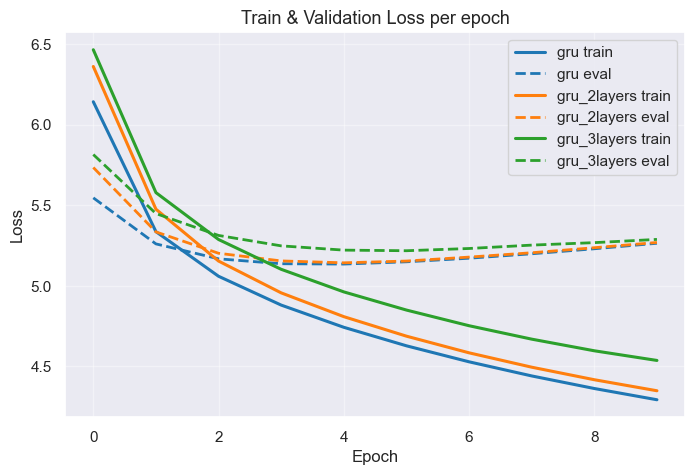

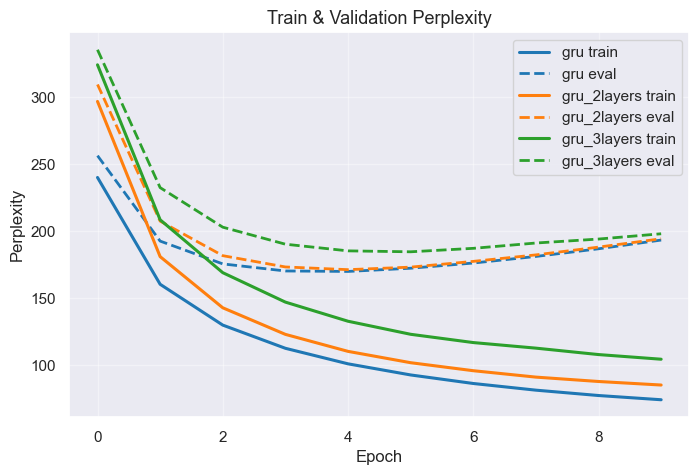

         model  final_train_loss  final_eval_loss  final_train_ppl  \
0          gru          4.293612         5.264893        74.200249   
1  gru_2layers          4.349436         5.269947        85.190430   
2  gru_3layers          4.537580         5.288938       104.463432   

   final_eval_ppl  
0      193.425537  
1      194.405579  
2      198.132904  


In [133]:
visualize_results(results, keys=["gru", "gru_2layers", "gru_3layers"])

### Второй эксперимент (2 балла)

Попробуйте что-то поменять в модели или в пайплайне обучения, идеи для экспериментов можно подсмотреть выше.

## 2 Добавление нормализаций в виде Dropout, BatchNorm или LayerNorm

In [134]:
results["gru_layernorm"] = train_and_eval(rnn_type="gru", use_norm=True, norm_type="layernorm", num_epoch=10)

gru H256 L1 epoch 0: 100%|█████████████████████████████████████████████████████████| 1388/1388 [00:50<00:00, 27.45it/s]


Epoch 0: train_loss=5.8350, eval_loss=5.3729, train_ppl=191.13, eval_ppl=215.49


gru H256 L1 epoch 1: 100%|█████████████████████████████████████████████████████████| 1388/1388 [00:50<00:00, 27.42it/s]


Epoch 1: train_loss=5.1919, eval_loss=5.2019, train_ppl=141.29, eval_ppl=181.62


gru H256 L1 epoch 2: 100%|█████████████████████████████████████████████████████████| 1388/1388 [00:50<00:00, 27.37it/s]


...

Epoch 7: train_loss=4.3844, eval_loss=5.2250, train_ppl=76.82, eval_ppl=185.87


gru H256 L1 epoch 8: 100%|█████████████████████████████████████████████████████████| 1388/1388 [00:50<00:00, 27.40it/s]


Epoch 8: train_loss=4.3100, eval_loss=5.2569, train_ppl=73.19, eval_ppl=191.89


gru H256 L1 epoch 9: 100%|█████████████████████████████████████████████████████████| 1388/1388 [00:50<00:00, 27.46it/s]


Epoch 9: train_loss=4.2440, eval_loss=5.2903, train_ppl=70.29, eval_ppl=198.40


In [135]:
results["gru_batchnorm"] = train_and_eval(rnn_type="gru", use_norm=True, norm_type="batchnorm", num_epoch=10)

gru H256 L1 epoch 0: 100%|█████████████████████████████████████████████████████████| 1388/1388 [00:50<00:00, 27.33it/s]


Epoch 0: train_loss=5.7513, eval_loss=5.3567, train_ppl=186.51, eval_ppl=212.03


gru H256 L1 epoch 1: 100%|█████████████████████████████████████████████████████████| 1388/1388 [00:50<00:00, 27.35it/s]


Epoch 1: train_loss=5.1768, eval_loss=5.2008, train_ppl=140.66, eval_ppl=181.42


gru H256 L1 epoch 2: 100%|█████████████████████████████████████████████████████████| 1388/1388 [00:50<00:00, 27.35it/s]


...

Epoch 7: train_loss=4.4112, eval_loss=5.2221, train_ppl=81.08, eval_ppl=185.32


gru H256 L1 epoch 8: 100%|█████████████████████████████████████████████████████████| 1388/1388 [00:50<00:00, 27.35it/s]


Epoch 8: train_loss=4.3438, eval_loss=5.2512, train_ppl=77.79, eval_ppl=190.79


gru H256 L1 epoch 9: 100%|█████████████████████████████████████████████████████████| 1388/1388 [00:50<00:00, 27.35it/s]


Epoch 9: train_loss=4.2851, eval_loss=5.2785, train_ppl=74.93, eval_ppl=196.07


In [136]:
results["gru_dropout"] = train_and_eval(rnn_type="gru", use_dropout=True, num_epoch=10)

gru H256 L1 epoch 0: 100%|█████████████████████████████████████████████████████████| 1388/1388 [00:50<00:00, 27.45it/s]


Epoch 0: train_loss=6.2103, eval_loss=5.5878, train_ppl=250.52, eval_ppl=267.14


gru H256 L1 epoch 1: 100%|█████████████████████████████████████████████████████████| 1388/1388 [00:50<00:00, 27.41it/s]


Epoch 1: train_loss=5.4231, eval_loss=5.3078, train_ppl=170.51, eval_ppl=201.91


gru H256 L1 epoch 2: 100%|█████████████████████████████████████████████████████████| 1388/1388 [00:50<00:00, 27.35it/s]


...

Epoch 7: train_loss=4.7055, eval_loss=5.1456, train_ppl=87.12, eval_ppl=171.67


gru H256 L1 epoch 8: 100%|█████████████████████████████████████████████████████████| 1388/1388 [00:50<00:00, 27.35it/s]


Epoch 8: train_loss=4.6519, eval_loss=5.1568, train_ppl=82.22, eval_ppl=173.62


gru H256 L1 epoch 9: 100%|█████████████████████████████████████████████████████████| 1388/1388 [00:50<00:00, 27.39it/s]


Epoch 9: train_loss=4.6028, eval_loss=5.1710, train_ppl=78.13, eval_ppl=176.08


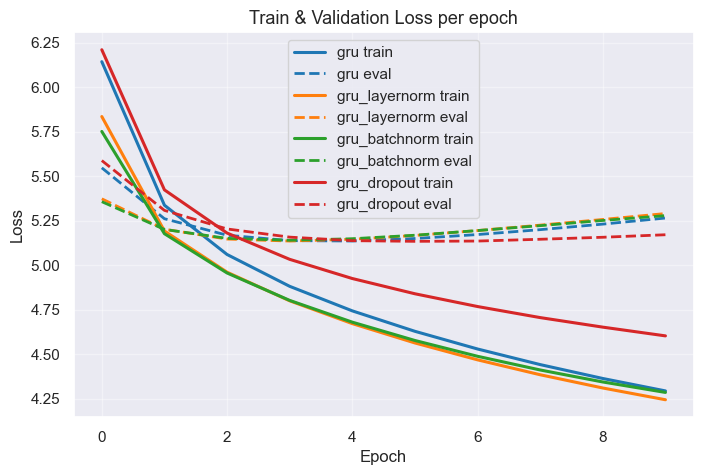

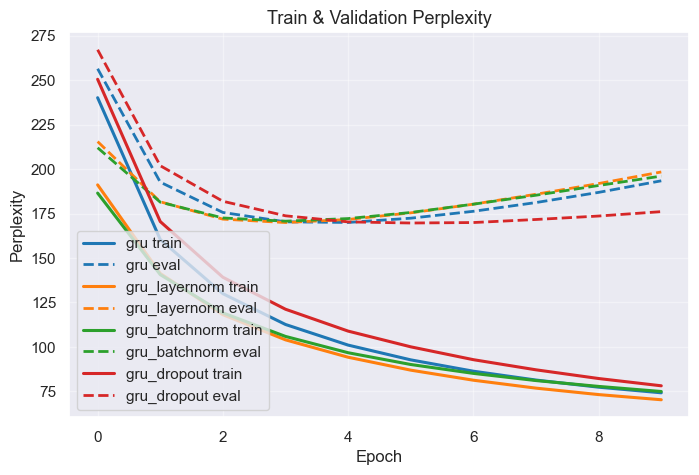

           model  final_train_loss  final_eval_loss  final_train_ppl  \
0    gru_dropout          4.602817         5.170962        78.134064   
1            gru          4.293612         5.264893        74.200249   
2  gru_batchnorm          4.285103         5.278491        74.929550   
3  gru_layernorm          4.243962         5.290284        70.288605   

   final_eval_ppl  
0      176.084213  
1      193.425537  
2      196.073868  
3      198.399704  


In [137]:
visualize_results(results, keys=["gru", "gru_layernorm", "gru_batchnorm", "gru_dropout"])

## Определим оптимальный LR, num_epoch and hidden_size

In [138]:
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK, space_eval
import numpy as np

In [139]:
space = {
    "lr": hp.choice("lr", [5e-3, 1e-3, 5e-4]),
    "num_epoch":  hp.choice("num_epoch",  [3, 5, 7, 10, 12]),
    "hidden_size": hp.choice("hidden_size", [192, 256, 384]),
}

In [140]:
best_model_state = None
best_score = float("inf")
best_params_global = None

def objective(params):
    global best_model_state, best_score, best_params_global

    result, model = train_and_eval(
        rnn_type="gru",
        num_layers=1,
        
        use_dropout=True,
        use_norm=True,
        norm_type="layernorm",
        hidden_size=int(params["hidden_size"]),
        lr=params["lr"],
        num_epoch=int(params["num_epoch"]),
        if_show=False,
        return_model=True
    )

    #best_acc = max(result["eval_acc"]) if result["eval_acc"] else 0.0
    best_ppls = result["eval_ppls"][-1] if result["eval_ppls"] else 1e6
    print(
        f"[Hyperopt] acc={best_ppls:.4f} | "
        f"lr={params['lr']} "
        f"hidden={params['hidden_size']} "
        f"epochs={params['num_epoch']}"
    )

    # сохраняем лучшую модель
    if best_ppls > best_score:
        best_score = best_ppls
        best_model_state = model.state_dict()
        best_params_global = params.copy()

    return {"loss": best_ppls, "status": STATUS_OK}


def run_hpopt(max_evals=20, seed=42):
    trials = Trials()
    best_idx = fmin(
        fn=objective,
        space=space,
        algo=tpe.suggest,
        max_evals=max_evals,
        trials=trials,
        rstate=np.random.default_rng(seed),
    )
    best_params = space_eval(space, best_idx)
    return best_params, trials

In [141]:
best_params, trials = run_hpopt(max_evals=30)
print("Best params:", best_params)

[Hyperopt] acc=190.0413 | lr=0.0005 hidden=256 epochs=3                                                                
[Hyperopt] acc=241.8900 | lr=0.005 hidden=256 epochs=12                                                                
[Hyperopt] acc=197.1313 | lr=0.005 hidden=192 epochs=3                                                                 
[Hyperopt] acc=173.8057 | lr=0.001 hidden=192 epochs=10                                                                
[Hyperopt] acc=169.3220 | lr=0.001 hidden=256 epochs=5                                                                 
[Hyperopt] acc=162.5948 | lr=0.0005 hidden=256 epochs=10                                                               
[Hyperopt] acc=169.2187 | lr=0.0005 hidden=192 epochs=10                                                               
[Hyperopt] acc=220.1920 | lr=0.005 hidden=384 epochs=7                                                                 
[Hyperopt] acc=189.9495 | lr=0.0005 hidd

### Отчет (2 балла)

Опишите проведенные эксперименты. Сравните перплексии полученных моделей. Предложите идеи по улучшению качества моделей.

## Генерирование текста

In [144]:
best_model = LanguageModel(
    vocab_size=len(word2ind),
    pad_id=word2ind['<pad>'],
    rnn_type="gru",
    num_layers=1,
    use_dropout=True,
    use_norm=True,
    norm_type="layernorm",
    hidden_size=int(best_params["hidden_size"])
).to(device)

best_model.load_state_dict(best_model_state)
best_model.eval()

LanguageModel(
  (embedding): Embedding(40004, 256, padding_idx=9342)
  (rnn): GRU(256, 384, batch_first=True)
  (norm): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (non_lin): ReLU()
  (linear): Linear(in_features=384, out_features=384, bias=True)
  (projection): Linear(in_features=384, out_features=40004, bias=True)
)

In [153]:
def generate_text(model, input_str: str, max_len: int, temperature: float = 1.0):
    model.eval()
    model.to('cpu')

    # токенизация
    input_str = input_str.lower().translate(str.maketrans('', '', string.punctuation))
    input_ids = [word2ind['<bos>']] + [
        word2ind.get(word, word2ind['<unk>']) for word in word_tokenize(input_str)
    ]
    input_ids = torch.LongTensor(input_ids).unsqueeze(0)  # [1, seq_len]

    generated = list(input_ids.squeeze().tolist())

    for _ in range(max_len):
        logits = model(input_ids)[0, -1]  # последний шаг
        logits = logits / temperature      # <-- температура
        probs = F.softmax(logits, dim=-1)
        next_word = torch.multinomial(probs, num_samples=1)  # выбор по вероятностям

        generated.append(next_word.item())
        if ind2word[next_word.item()] == '<eos>':
            break

        input_ids = torch.LongTensor(generated).unsqueeze(0)

    words = [ind2word[i] for i in generated if i not in {word2ind['<bos>'], word2ind['<pad>']}]
    return ' '.join(words)

In [158]:
generate_text(best_model, 'The movie was good', max_len=100)

'the movie was good and i was very surprised to watch it <eos>'

In [161]:
generate_text(best_model, 'The movie was bad', max_len=100)

'the movie was bad and i didnt like it <eos>'

In [185]:
for i in range(5):
    print(generate_text(best_model, 'The movie was bad', max_len=100, temperature=2))

the movie was bad <eos>
the movie was bad really funny demon or even the monster fire <eos>
the movie was bad and so few more can happen that the feelings of the film was a bit of parody of a movie and very grim at <eos>
the movie was bad but got obvious <eos>
the movie was bad acting to hold a big budget movie special sound dialog score like special effects <eos>


In [184]:
for i in range(5):
    print(generate_text(best_model, 'The movie was bad', max_len=100, temperature=0.1))

the movie was bad and i didnt like it <eos>
the movie was bad and i didnt like it <eos>
the movie was bad and i didnt like it <eos>
the movie was bad and i didnt like it <eos>
the movie was bad and i didnt like it <eos>


In [189]:
for i in range(5):
    print(generate_text(best_model, 'The movie was bad', max_len=100, temperature=1))

the movie was bad and the story is very good <eos>
the movie was bad but it wasnt funny <eos>
the movie was bad and it looks like a good movie but it was very funny <eos>
the movie was bad and i didnt like it <eos>
the movie was bad <eos>
